## Classification of Iris Species using Logistic Regression

### Importing Required Libraries

In [1]:
# Numerical Calculations
import numpy as np # Numpy: Numerical Python

# Data Manipulation (Handling dataframes)
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt # pyplot: Module within matplotlib that provides MATLAB like interface for plotting
%matplotlib inline
# Accessing models and packages of Machine Learning
import sklearn # sklearn: scikit learn

# Data visualization
import seaborn as sns # Seaborn: A visualization library built on top of matplotlib to use matplotlib easily

# To ignore warnings
import warnings
warnings.filterwarnings('ignore') # ignore all warnings (especially non-critical) so that they won't be printed in the output
# Settig the warning filter to ignore FutureWarning
warnings.simplefilter(action = 'ignore', category = FutureWarning) # FutureWarning: A warning about a feature i.e numpy, pandas that might change in future

### Loading the dataset

In [2]:
# Loading all the dataset
full_data = pd.read_csv('/content/iris.data') # Replace with file path

In [3]:
# Checking Shape of the dataset
full_data.shape # To check rows and columns of data, 1st element shows rows while 2nd element shows columns

(149, 5)

In [4]:
# Display first five rows of the data
full_data.head()

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [5]:
# Display last five rows of data
full_data.tail()

,5.1,3.5,1.4,0.2,Iris-setosa
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica
148,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
# Renaming the attributes for best understanding
full_data = full_data.rename(columns={
    '5.1': 'sepal_length',
    '3.5': 'sepal_width',
    '1.4': 'petal_length',
    '0.2': 'petal_width',
    'Iris-setosa': 'species'
})

# Checking the dataset again to ensure the attributes have been renamed
full_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [7]:
# Information about the dataset
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


### Preprocessing the data

In [8]:
# checking missing values
full_data.isnull().sum()  # counts all missing values in each column and shows them

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [9]:
# checking duplicate rows
full_data.duplicated().sum()

np.int64(3)

In [10]:
# check dataset shape
full_data.shape

(149, 5)

In [11]:
# removing all the duplicate rows
full_data = full_data.drop_duplicates()

# again check duplicate rows to make make sure that it has been removed
full_data.duplicated().sum()

np.int64(0)

In [12]:
# check data shape
full_data.shape

(146, 5)

In [13]:
# Data information
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  146 non-null    float64
 1   sepal_width   146 non-null    float64
 2   petal_length  146 non-null    float64
 3   petal_width   146 non-null    float64
 4   species       146 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.8+ KB


### As the problem is a binary classification problem, so we have to convert all object data types into category data type

In [14]:
full_data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [15]:
# Converting values of variable 'species' into numbers as we know that ML models shows best performance on numerical data
from sklearn.preprocessing import LabelEncoder # LabelEncoder will convert all the unique data of variable 'species' into numbers i.e (0, 1, 2)
le = LabelEncoder() # instance of the above module
full_data['species'] = le.fit_transform(full_data['species']) # fitting variable 'species' and transforming its values

In [16]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  146 non-null    float64
 1   sepal_width   146 non-null    float64
 2   petal_length  146 non-null    float64
 3   petal_width   146 non-null    float64
 4   species       146 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.8 KB


In [17]:
# Description of all attributes
full_data.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,5.861644,3.052740,3.796575,1.215753,1.013699
std,0.829562,0.436948,1.753987,0.755822,0.813560
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.400000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


<Axes: >

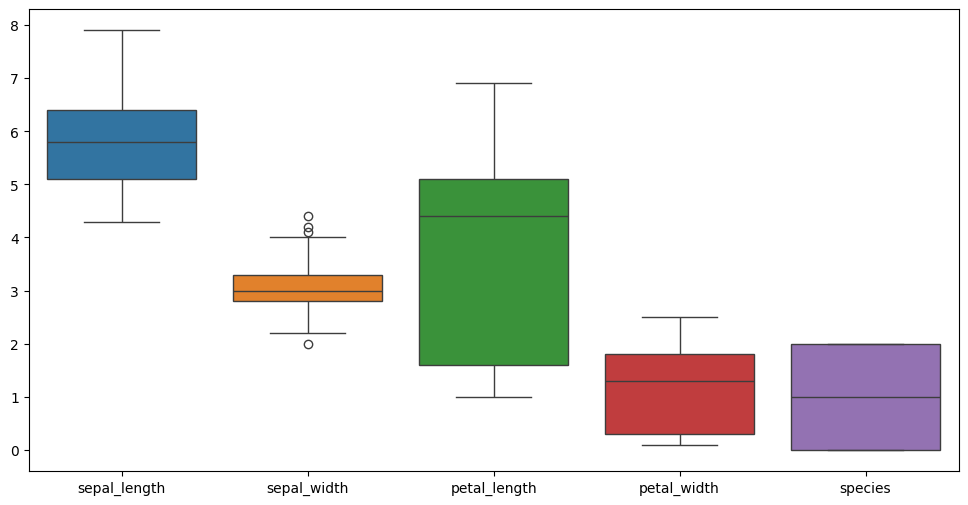

In [18]:
# Detecting outliers in data
plt.figure(figsize=(12,6)) # figsize=(width, height)
sns.boxplot(full_data)

In [19]:
# from the above plot we noticed some 'outliers' in the variable 'sepal_width', so we have to handle it
Q1 = full_data['sepal_width'].quantile(0.25) # First 25% data of the attribute
Q3 = full_data['sepal_width'].quantile(0.75) # Data between 50% and 75%
IQR = Q3 - Q1 # Interquartile Range

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Dropping out outliers
full_data = full_data[(full_data['sepal_width'] >= lower_bound) & (full_data['sepal_width'] <= upper_bound)]

# If number of outliers are more, then we can not simply drop it, as it will leads to decreasing the instances (rows) of data.
# In such cases we have to replace the outliers by median, mean or mode of that specific attribute (column)

In [20]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  142 non-null    float64
 1   sepal_width   142 non-null    float64
 2   petal_length  142 non-null    float64
 3   petal_width   142 non-null    float64
 4   species       142 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.7 KB


<Axes: >

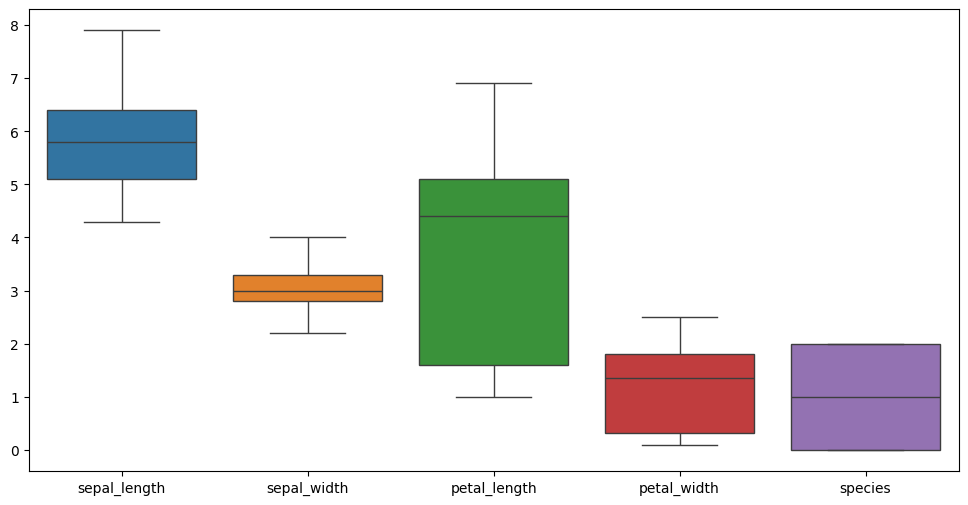

In [21]:
# Now again check the outliers to make sure that it have been removed successfully
plt.figure(figsize=(12,6))
sns.boxplot(full_data)

In [22]:
# Finding correlation of all the data
full_data.corr()

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.106511,0.878594,0.820689,0.786979
sepal_width,-0.106511,1.000000,-0.389647,-0.320522,-0.388476
petal_length,0.878594,-0.389647,1.000000,0.960252,0.946049
petal_width,0.820689,-0.320522,0.960252,1.000000,0.954186
species,0.786979,-0.388476,0.946049,0.954186,1.000000


<Axes: >

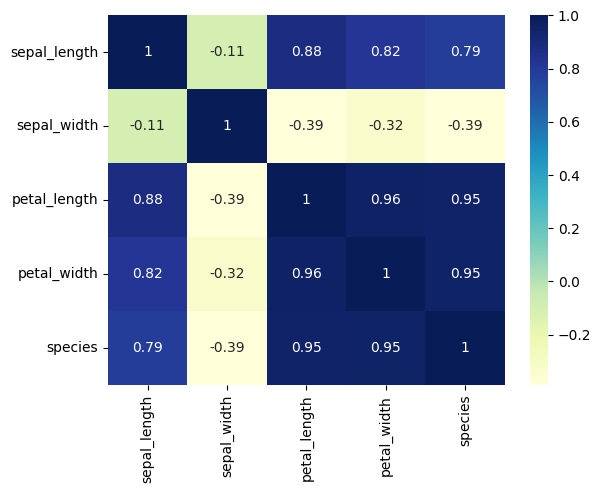

In [23]:
# Correlation using heatmap
# Yl-> Yellow, Gn-> Green, Bu-> Blue *********** cmap takes color input in the format 'Low,Medium,High'
sns.heatmap(full_data.corr(), annot=True, cmap='YlGnBu') # annot=True: means to display both the colored grid and actual value of each cell

### Now getting the dataset ready for training the model

In [24]:
full_data.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.9,3.0,1.4,0.2,0
1,4.7,3.2,1.3,0.2,0


In [25]:
# seperating features and target (here target is 'species)
x = full_data.drop("species", axis = 1) # Features
y = full_data["species"] # Target (attribute that we are trying to predict)

In [26]:
x.shape # Features shape

(142, 4)

In [27]:
y.shape # Target shape

(142,)

In [28]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,4.9,3.0,1.4,0.2
1,4.7,3.2,1.3,0.2
2,4.6,3.1,1.5,0.2
3,5.0,3.6,1.4,0.2
4,5.4,3.9,1.7,0.4
...,...,...,...,...
144,6.7,3.0,5.2,2.3
145,6.3,2.5,5.0,1.9
146,6.5,3.0,5.2,2.0
147,6.2,3.4,5.4,2.3


In [29]:
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
144,2
145,2
146,2
147,2


Text(0.5, 1.0, 'Class Distribution')

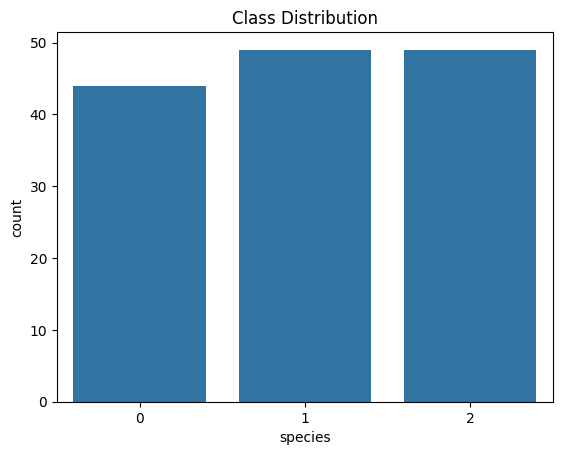

In [30]:
# We can also check if the target 'y' has balanced or imbalanced data
sns.countplot(x=y) # y is the above target column
plt.title("Class Distribution")

### As all the classes a reasonable same height, so the the classes are reasonable balanced. While in imbalanced data bar charts of some classes are too high and some are too short.

In [31]:
y.unique() # identifies all the unique values in 'y'

array([0, 1, 2])

In [32]:
# Transforming (scaling) data into a common range
from sklearn import preprocessing
# initializing and fitting scaler "StandardScaler" to scale the data,        std_scaler= (x-mean)/standard deviation
scaler = preprocessing.StandardScaler()      # .fit() Calculates and stores parameters (e.g., mean, std), no transformation.
# Applying the scaler to scale the feature,    .transform() Transforms data using stored parameters from a prior .fit().
x_scaled = scaler.fit_transform(x)           # .fit_transform() Combines fit and transform in one step.

In [33]:
x_scaled

array([[-1.17241262, -0.08884541, -1.40778965, -1.38490781],
       [-1.41264724,  0.41579653, -1.46530005, -1.38490781],
       [-1.53276455,  0.16347556, -1.35027926, -1.38490781],
       [-1.05229531,  1.4250804 , -1.40778965, -1.38490781],
       [-0.57182607,  2.1820433 , -1.23525847, -1.11807347],
       [-1.53276455,  0.92043846, -1.40778965, -1.25149064],
       [-1.05229531,  0.92043846, -1.35027926, -1.38490781],
       [-1.77299917, -0.34116638, -1.40778965, -1.38490781],
       [-1.17241262,  0.16347556, -1.35027926, -1.51832498],
       [-0.57182607,  1.67740137, -1.35027926, -1.38490781],
       [-1.29252993,  0.92043846, -1.29276886, -1.38490781],
       [-1.29252993, -0.08884541, -1.40778965, -1.51832498],
       [-1.89311648, -0.08884541, -1.58032084, -1.51832498],
       [-0.09135683,  2.43436427, -1.52281044, -1.38490781],
       [-0.57182607,  2.1820433 , -1.46530005, -1.11807347],
       [-0.932178  ,  1.17275943, -1.40778965, -1.25149064],
       [-0.21147414,  1.

In [34]:
# Now Splitting the data into training and testing data
from sklearn.model_selection import train_test_split # Module for splitting data

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [35]:
x_train.shape

(113, 4)

In [36]:
x_test.shape

(29, 4)

In [37]:
y_train.shape

(113,)

In [38]:
y_test.shape

(29,)

### Now the data is ready for the model

In [39]:
# importing "logistic regression" model
from sklearn.linear_model import LogisticRegression

# initializing a regressor (An instance of the model)
Log_reg = LogisticRegression()

# Fitting the model on the training data
Log_reg.fit(x_train, y_train) # .fit method sets the data to the model and begins training on train data

LogisticRegression()

In [40]:
# Making predictions
y_pred = Log_reg.predict(x_test) # .predict method makes predictions on test data (unseen) from the trained model
# Display the predicted values
print(y_pred)

[2 0 1 2 1 0 2 1 1 0 1 1 2 2 2 1 0 1 2 1 0 2 2 2 1 1 0 0 0]


In [41]:
# Evaluating the model on different evaluation metrices like accuracy_score, precision, recall, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("******** Logistic Regression *********")

# Accuracy
Log_reg_accuracy = accuracy_score(y_test, y_pred) # y_test is the actual output while, y_pred is the predicted output
print("Accuracy:  ", Log_reg_accuracy)

# Precision
Log_reg_precision = precision_score(y_test, y_pred, average='weighted') # average='weighted': find precision of each class and take average of them
print("Precision: ", Log_reg_precision)

# Recall
Log_reg_recall= recall_score(y_test, y_pred, average='weighted')
print("Recall:    ", Log_reg_recall)

# f1_score
Log_reg_f1_score = f1_score(y_test, y_pred, average='weighted')
print("f1_score:  ", Log_reg_f1_score)

******** Logistic Regression *********
Accuracy:   1.0
Precision:  1.0
Recall:     1.0
f1_score:   1.0


### As the dataset is so simple (small amount of data), so the evaluation metric (accuracy) shows 100%, which is an ideal case, so we have try other classification models

In [42]:
# Training a decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(x_train, y_train)

DecisionTreeClassifier()

In [43]:
# Making predictions
y_pred_dt = dt_classifier.predict(x_test) # .predict method makes predictions on test data (unseen) from the trained model
print(y_pred_dt)

[2 0 1 2 1 0 2 1 1 0 2 1 2 2 2 1 0 1 2 1 0 2 2 1 1 1 0 0 0]


In [44]:
# Evaluating the model on different evaluation metrices like accuracy_score, precision, recall, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("******** Decision Tree Classifier *********")

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt) # y_test is the actual output while, y_pred is the predicted output
print("Accuracy:  ", dt_accuracy)

# Precision
dt_precision = precision_score(y_test, y_pred_dt, average='weighted') # average='weighted': find precision of each class and take average of them
print("Precision: ", dt_precision)

# Recall
dt_recall= recall_score(y_test, y_pred_dt, average='weighted')
print("Recall:    ", dt_recall)

# f1_score
dt_f1_score = f1_score(y_test, y_pred_dt, average='weighted')
print("f1_score:  ", dt_f1_score)

******** Decision Tree Classifier *********
Accuracy:   0.9310344827586207
Precision:  0.9310344827586207
Recall:     0.9310344827586207
f1_score:   0.9310344827586207


In [45]:
# Training a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier()
rf_classifier.fit(x_train, y_train)

RandomForestClassifier()

In [46]:
# Making predictions
y_pred_rf = rf_classifier.predict(x_test) # .predict method makes predictions on test data (unseen) from the trained model
print(y_pred_rf)

[1 0 1 2 1 0 2 1 1 0 1 1 2 2 2 1 0 1 2 1 0 2 2 1 1 1 0 0 0]


In [47]:
# Evaluating the model on different evaluation metrices like accuracy_score, precision, recall, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("******** Random Forest *********")

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf) # y_test is the actual output while, y_pred is the predicted output
print("Accuracy:  ", rf_accuracy)

# Precision
rf_precision = precision_score(y_test, y_pred_rf, average='weighted') # average='weighted': find precision of each class and take average of them
print("Precision: ", rf_precision)

# Recall
rf_recall= recall_score(y_test, y_pred_rf, average='weighted')
print("Recall:    ", rf_recall)

# f1_score
rf_f1_score = f1_score(y_test, y_pred_rf, average='weighted')
print("f1_score:  ", rf_f1_score)

******** Random Forest *********
Accuracy:   0.9310344827586207
Precision:  0.9416445623342174
Recall:     0.9310344827586207
f1_score:   0.9300766283524904


In [48]:
# Comparing accuracy score of all the models
models_accuracy = {
    'Logistic Regression' : Log_reg_accuracy,
    'Decision Tree' : dt_accuracy,
    'Random Forest' : rf_accuracy
}
# Displaying keys (Models Names) and values (accuracy) side by side
pd.DataFrame(list(models_accuracy.items()), columns=['Model', 'Accuracy'])


,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,0.931034
2,Random Forest,0.931034


<Axes: >

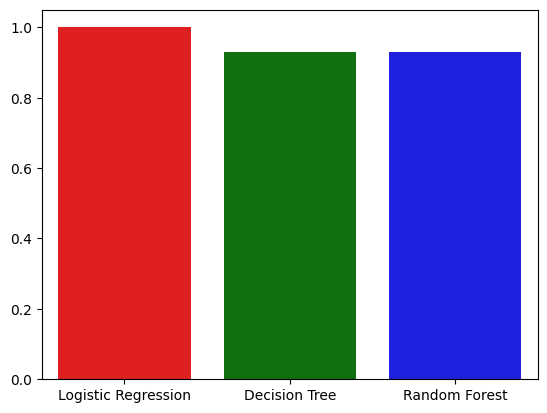

In [49]:
# We can also visualize accuracy score of all the three models using seaborn
colors = ['red', 'green', 'blue']
sns.barplot(x=list(models_accuracy.keys()), y=list(models_accuracy.values()), palette=colors)

### From the above result we have to consider a reasonable model. So based on the results we can not consider logistic regression as it shows an ideal result i.e accuracy = 100%.
### According to the results we can consider Random Forest with accuracy = 96% as a reasonable model.

In [50]:
# Printing actual result (y_test) and predicted result (y_pred_rf) of Random forest model side by side
for actual, predicted in zip(y_test, y_pred_rf): # zip() function pairs up the elements from both sequences positionally
    print(f"Actual: {actual}, Predicted: {predicted}")


Actual: 2, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 2, Predicted: 2
Actual: 2, Predicted: 2
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 2, Predicted: 2
Actual: 2, Predicted: 2
Actual: 2, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0


### If we notice the above result carefully, the 6th value from bottom side is predicted wrong ie Actual: 2, Predicted:1, due to which model shows accuracy=96%. Rest of all are predicted accurately.

### Now lets save and download the randon forest classifier to integrate it with user interface

In [51]:
# Saving the dt_classifier model using 'joblib' to use it later for real world predictions
import joblib
joblib.dump(rf_classifier, 'rf_iris_model.pkl')

['rf_iris_model.pkl']

In [52]:
# We also have to save the LabelEncoder that transformed values in 'species' attribute into numbers
# This is because we will use the 'inverse transform' method to get the predicted output in nominal form, rather than in numerical
joblib.dump(le, 'lebel_encoder.pkl')

['lebel_encoder.pkl']

In [53]:
# We also have to save the scaler i.e here (Standard Scaler) that transformed all the features into a common range
# So that during real time pediction the scaler should also transform the input data
# So when we enter the input, the model should check the scaled input with the scaled features, not the raw input
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [54]:
# Downloading the saved model and lebel_encoder
from google.colab import files
files.download('rf_iris_model.pkl') # Download the Model
files.download('lebel_encoder.pkl') # Download the LebelEncoder
files.download('scaler.pkl') # Download the scaler

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Now the rf_classifier model, lebel_encoder and scaler, all have been downloaded to our local pc repository